In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("HR.csv")
print(df.head())
print(df.shape)
print(df.info())
print(df.columns.tolist())
print(df.dtypes)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [3]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole    

In [4]:
print("\nAttrition counts:\n", df["Attrition"].value_counts())
print("\nAttrition %:\n", df["Attrition"].value_counts(normalize=True) * 100)


Attrition counts:
 Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition %:
 Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


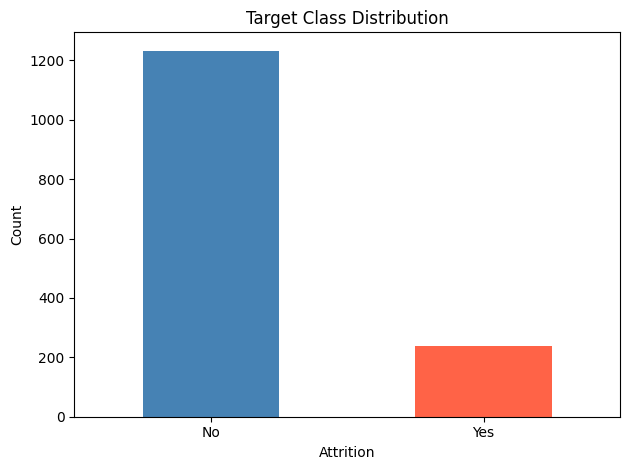

In [ ]:
# Visualizations
df["Attrition"].value_counts().plot(kind="bar", color=["steelblue", "tomato"])
plt.title("Target Class Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:

# These 3 columns have only ONE unique value 
print(df["EmployeeCount"].unique())   # always 1
print(df["Over18"].unique())          # always 'Y'
print(df["StandardHours"].unique())   # always 80

df = df.drop(columns=["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"])
# EmployeeNumber is just an ID so its basically irrelevant to prediction

[1]
<StringArray>
['Y']
Length: 1, dtype: str
[80]


In [ ]:
# Separate feature types 
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols.remove("Attrition")  # target, not a feature
numerical_cols = df.select_dtypes(include="number").columns.tolist()

print("\nCategorical features:", categorical_cols)
print("\nNumerical features:", numerical_cols)


Categorical features: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


C:\Users\shrad\AppData\Local\Temp\ipykernel_27528\2957205058.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()
